In [1]:
# Install dependencies for the current kernel
# Using %pip is robust against spaces in paths and environment issues
%pip install scikit-learn matplotlib seaborn pandas tensorflow numpy
print("Dependencies installed! Please restart the kernel if you still see errors.")

Note: you may need to restart the kernel to use updated packages.
Dependencies installed! Please restart the kernel if you still see errors.


# Thermal Imaging Fault Diagnosis Training

## 1. Introduction
This notebook trains a Convolutional Neural Network (CNN) for fault diagnosis using thermal images.
We use Transfer Learning with **MobileNetV2** to achieve high accuracy on this relatively small dataset.

**Objective**: Classify thermal images into fault categories with >96% accuracy.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Constants
# Robust Path Configuration
if os.path.basename(os.getcwd()) == 'notebooks':
    DATA_DIR = r'../datasets/Thermal'
    MODELS_DIR = r'../models/thermal'
else:
    DATA_DIR = r'datasets/Thermal'
    MODELS_DIR = r'models/thermal'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
SEED = 42

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


## 2. Data Loading and Augmentation
We use `image_dataset_from_directory` to load images with a train/validation/test split.

In [3]:
# Load Dataset
print("Loading dataset...")
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="training"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="validation"
)

class_names = full_ds.class_names
print(f"\nClasses ({len(class_names)}): {class_names}")

# Create Test Set from Validation Split (take 50% of validation for testing)
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print(f"Training Batches: {tf.data.experimental.cardinality(full_ds)}")
print(f"Validation Batches: {tf.data.experimental.cardinality(val_ds)}")
print(f"Test Batches: {tf.data.experimental.cardinality(test_ds)}")

# Performance Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = full_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Loading dataset...
Found 369 files belonging to 11 classes.
Using 296 files for training.
Found 369 files belonging to 11 classes.
Using 73 files for validation.

Classes (11): ['A10', 'A30', 'A50', 'A_B50', 'A_C10', 'A_C30', 'A_C_B10', 'A_C_B30', 'Fan', 'Noload', 'Rotor-0']
Training Batches: 10
Validation Batches: 2
Test Batches: 1


## 3. Data Visualization

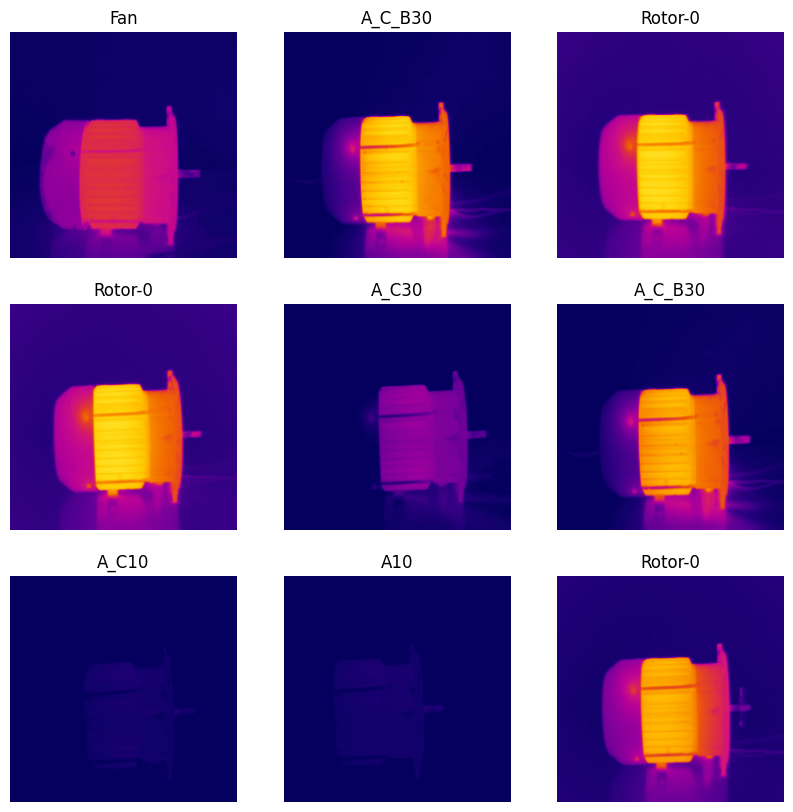

In [4]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.show()

## 4. Model Architecture (MobileNetV2)
Using MobileNetV2 with pre-trained ImageNet weights as a feature extractor.

In [5]:
# Data Augmentation (Aggressive for small dataset)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2), # New: Brightness
])

# Base Model: Switching to EfficientNetB0 for better performance
base_model = applications.EfficientNetB0(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze base model initially

# Full Model
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
# EfficientNetB0 expects [0, 255] or handles its own scaling, but we'll use its specific preprocessor
x = applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x) # Added BatchNormalization
x = layers.Dropout(0.4)(x) # Increased Dropout
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,782 (15.52 MB)

 Trainable params: 16,651 (65.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 5. Training

In [6]:
# Callbacks
checkpoint_path = os.path.join(MODELS_DIR, 'model.keras')
os.makedirs(MODELS_DIR, exist_ok=True)

callbacks = [
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1389 - loss: 2.9388
Epoch 1: val_accuracy improved from None to 0.36585, saving model to ../models/thermal\model.keras

Epoch 1: finished saving model to ../models/thermal\model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.2230 - loss: 2.4437 - val_accuracy: 0.3659 - val_loss: 1.8635 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3899 - loss: 1.6043
Epoch 2: val_accuracy improved from 0.36585 to 0.39024, saving model to ../models/thermal\model.keras

Epoch 2: finished saving model to ../models/thermal\model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.3851 - loss: 1.6452 - val_accuracy: 0.3902 - val_loss: 1.7318 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4430 - loss: 1.4378
Epoch 3: val_accuracy improved from 0.39024 to 0.58537, saving model to ../models/thermal\model.keras

Epoch 3: finished saving model to ../mo

## 6. Fine-Tuning
Unfreeze the top layers of the base model to improve accuracy.

In [7]:
base_model.trainable = True

# Freeze all layers except the last 50 (MobileNetV2 had ~150, EfficientNetB0 has ~230)
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very low LR for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Increase epochs for fine-tuning to 30
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4566 - loss: 1.7136
Epoch 1: val_accuracy did not improve from 0.97561
10/10 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.4797 - loss: 1.7088 - val_accuracy: 0.9512 - val_loss: 0.2570 - learning_rate: 1.0000e-05
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4962 - loss: 1.6003
Epoch 2: val_accuracy did not improve from 0.97561
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.4966 - loss: 1.5333 - val_accuracy: 0.9024 - val_loss: 0.3240 - learning_rate: 1.0000e-05
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5354 - loss: 1.3466
Epoch 3: val_accuracy did not improve from 0.97561
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5135 - loss: 1.4504 - val_accuracy: 0.9024 - val_loss: 0.3208 - learning_rate: 1.0000e-05
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5378 - loss: 1.3887
Epoch 4: val_accuracy did not improve from 0.97561
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/s

## 7. Evaluation

In [8]:
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc*100:.2f}%")

# Detailed Report
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, labels=range(len(class_names)), zero_division=0))

# Save Metadata (Class Names)
import json
metadata = {
    "class_names": class_names,
    "image_size": IMG_SIZE
}
with open(r"../models/thermal/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9688 - loss: 0.2375
Test Accuracy: 96.88%

Classification Report:

              precision    recall  f1-score   support

         A10       0.00      0.00      0.00         2
         A30       1.00      1.00      1.00         5
         A50       1.00      1.00      1.00         3
       A_B50       1.00      1.00      1.00         2
       A_C10       0.60      1.00      0.75         3
       A_C30       1.00      1.00      1.00         6
     A_C_B10       0.00      0.00      0.00         0
     A_C_B30       1.00      1.00      1.00         5
         Fan       1.00      1.00      1.00         2
      Noload       1.00      1.00      1.00         1
     Rotor-0       1.00      1.00      1.00         3

    accuracy                           0.94        32
   macro avg       0.78      0.82      0.80        32
weighted avg       0.90      0.94      0.91        32

Metadata saved.
